# NeuroDrift — 3-Stage EEG Pipeline

**Stage 1 — Global Acceptance Model**  
Trained once on multi-subject (subjects 1–8) data. Positives: clean MI trials that
pass raw data-quality and neurophysiological-separability criteria. Negatives:
CorruptionEngine outputs + clean trials with weak ERD lateralization.
Uses 8 raw-EEG features — no CSP or LDA required. Model is **frozen** after training.

**Stage 2 — Per-Subject Calibration & Inference (Subject 9)**  
Each calibration trial is gated through the frozen acceptance model first.
Only accepted trials accumulate; CSP+LDA is fitted once min trials per class
are buffered. Adaptive stopping then decides when calibration is sufficient.
The same gate operates at inference time (pseudo-online engine).

**Stage 3 — Longitudinal Analysis (Layers 6 & 7)**  
Controlled degradation model, session-level feature regression, clustering,
cross-prior generalisation, assistance simulation, and domain profiling.

---
## Stage 0 — Imports, Constants & Utilities

In [70]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple

from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery
from mne.decoding import CSP
from mne.time_frequency import psd_array_welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_predict, LeaveOneOut, StratifiedKFold, cross_val_score,
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, r2_score, mean_squared_error, silhouette_score,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from scipy import stats as sp_stats
from mne.decoding import CSP as CSP_cls
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA_cls

from feature_extractor import FeatureExtractor, RawQualityExtractor
from corruption_engine import CorruptionEngine
from degradation_model import (
    DegradationModel, DegradationParams,
    prior_default, prior_alt, r_to_params, sample_params_uniform,
)

In [71]:
# tmin=-2 extends each epoch 2 s backwards into the pre-cue fixation window.
# Trial structure at 250 Hz:
#   samples [0   : 500 ) -> 2 s baseline (pre-cue rest, ERD reference)
#   samples [500 : 1500) -> 4 s motor imagery window
paradigm = LeftRightImagery(tmin=-2)
dataset  = BNCI2014_001()

sfreq            = 250
BASELINE_SAMPLES = int(2.0 * sfreq)   # 500
TASK_SAMPLES     = int(4.0 * sfreq)   # 1000

# Subjects used for global acceptance model training vs held-out test.
# GLOBAL_TRAIN_SUBJECTS = list(range(1, 9))   # subjects 1–8
GLOBAL_TRAIN_SUBJECTS = [1, 3, 4, 5, 6, 7, 8, 9]
HELD_OUT_SUBJECT      = 2

# BCI timing constants (BNCI2014_001 paradigm)
ITI_S                  = 1.5
FEEDBACK_DELAY_S       = 0.2
CLASSIFICATION_DELAY_S = 0.05

ch_names = [
    "Fz",  "FC3", "FC1", "FCz", "FC2", "FC4",
    "C5",  "C3",  "C1",  "Cz",  "C2",  "C4",  "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "P1",  "Pz",  "P2",  "POz",
]


def task_view(epochs):
    """Slice the imagery-only window. CSP/LDA must not see the rest baseline."""
    return epochs[..., BASELINE_SAMPLES:]


def baseline_view(epochs):
    """Slice the pre-cue rest window (ERD reference)."""
    return epochs[..., :BASELINE_SAMPLES]


def _adaptive_calibration_stop(
    X_pool, y_pool,
    min_trials=48, step=12, max_trials=132, patience=2,
    eps_acc=0.005, eps_conf=0.005,
):
    """Return calibration cutoff index + history.

    Lightweight CSP+LDA validation loop on the accepted calibration pool.
    Stops when both validation accuracy and confidence improvements plateau
    for `patience` consecutive expansions.
    """
    n = len(X_pool)
    assert n >= min_trials + step, "Not enough accepted trials for adaptive calibration."

    history = []
    stable  = 0
    cut     = min_trials

    for n_cal in range(min_trials, min(max_trials, n - step) + 1, step):
        X_cal, y_cal = X_pool[:n_cal], y_pool[:n_cal]
        X_val, y_val = X_pool[n_cal:], y_pool[n_cal:]

        if len(X_val) < 12:
            break

        csp_tmp = CSP(n_components=6, reg=None, log=True, norm_trace=False)
        Xc_cal  = csp_tmp.fit_transform(task_view(X_cal), y_cal)
        ld_tmp  = LDA()
        ld_tmp.fit(Xc_cal, y_cal)

        Xc_val = csp_tmp.transform(task_view(X_val))
        acc_val  = float(np.mean(ld_tmp.predict(Xc_val) == y_val))
        conf_val = float(np.mean(np.max(ld_tmp.predict_proba(Xc_val), axis=1)))

        history.append({"n_cal": int(n_cal), "n_val": int(len(X_val)),
                         "val_acc": acc_val, "val_conf": conf_val})

        if len(history) >= 2:
            da = history[-1]["val_acc"]  - history[-2]["val_acc"]
            dc = history[-1]["val_conf"] - history[-2]["val_conf"]
            if abs(da) < eps_acc and abs(dc) < eps_conf:
                stable += 1
            else:
                stable = 0
            if stable >= patience:
                cut = int(n_cal)
                break
        cut = int(n_cal)

    return cut, history


def _split_remaining_into_sessions(X_rem, y_rem, n_sessions=6):
    """Evenly partition remaining post-calibration trials into synthetic sessions."""
    n = len(X_rem)
    if n == 0:
        return []
    bounds = np.linspace(0, n, n_sessions + 1, dtype=int)
    return [
        {"session_idx": i, "X": X_rem[a:b], "y": y_rem[a:b], "n_trials": int(b - a)}
        for i, (a, b) in enumerate(zip(bounds, bounds[1:])) if b > a
    ]

---
## Stage 1 — Global Acceptance Model

The acceptance model is trained **once** on multi-subject data and then **frozen**.  
It classifies each EEG trial as *accept* (quality sufficient for MI classification)
or *reject* using **8 raw-EEG features only** — no CSP, no LDA, no prediction outcome.

| Feature group | Features |
|---|---|
| Artifact signals | `peak_to_peak_max`, `kurtosis_max`, `baseline_p2p_max` |
| Neurophysiological separability | `erd_mu_c3`, `erd_mu_c4`, `erd_lat_mu`, `mu_ratio_motor`, `motor_relative_power` |

**Positive class** (accept=1): clean trials that pass both artifact and separability thresholds  
**Negative class** (accept=0):
- *Hard negatives* — CorruptionEngine outputs (artifact / disengagement / SNR / implausibility)
- *Borderline negatives* — clean trials with weak ERD lateralization (`|erd_lat_mu| < threshold`)

> Labels are derived solely from signal quality and neurophysiological separability.
> Prediction correctness (mismatch between LDA output and true label) is **never used**.

In [72]:
# Load all trials from subjects 1–8 (both sessions per subject).
# Each subject contributes 288 trials (144 train + 144 test) -> 2304 total.
all_epochs, all_labels = [], []

for subj in GLOBAL_TRAIN_SUBJECTS:
    X_s, y_s, _ = paradigm.get_data(dataset, subjects=[subj])
    all_epochs.append(X_s[0:144])
    all_labels.append(y_s[0:144])

X_global = np.concatenate(all_epochs, axis=0)
y_global = np.concatenate(all_labels, axis=0)

print(f"Multi-subject pool: {X_global.shape[0]} trials from {len(GLOBAL_TRAIN_SUBJECTS)} subjects")
print(f"Epoch shape: {X_global.shape[1:]}  (channels x samples)")
print(f"Class distribution: {Counter(y_global)}")

Multi-subject pool: 1152 trials from 8 subjects
Epoch shape: (22, 1501)  (channels x samples)
Class distribution: Counter({np.str_('right_hand'): 576, np.str_('left_hand'): 576})


In [73]:
# Instantiate the raw-quality extractor (no CSP / LDA dependency).
rqe = RawQualityExtractor(
    ch_names=ch_names,
    sfreq=sfreq,
    baseline_samples=BASELINE_SAMPLES,
)

print("Extracting 8-d raw quality features for all multi-subject trials...")
F_global = rqe.extract_many(X_global)    # shape: (n_trials, 8)
print(f"Feature matrix: {F_global.shape}")
print("\nFeature summary (mean ± std):")
for j, name in enumerate(rqe.feature_names):
    print(f"  {name:24s}  {F_global[:, j].mean():.4f} ± {F_global[:, j].std():.4f}")

Extracting 8-d raw quality features for all multi-subject trials...
Feature matrix: (1152, 8)

Feature summary (mean ± std):
  peak_to_peak_max          47.3365 ± 16.8578
  kurtosis_max              1.0723 ± 1.1983
  baseline_p2p_max          46.7958 ± 18.1842
  erd_mu_c3                 -0.0818 ± 0.7082
  erd_mu_c4                 -0.0928 ± 0.6614
  erd_lat_mu                0.0110 ± 0.7309
  mu_ratio_motor            0.7535 ± 0.1059
  motor_relative_power      1.0012 ± 0.0983


In [74]:
# ---------------------------------------------------------------------------
# Thresholds for quality criteria — derived from the clean-data distribution.
# Artifact thresholds: 95th percentile of p2p across all clean trials.
# Separability threshold: 0.05 for |erd_lat_mu| (weak but present lateralization).
# ---------------------------------------------------------------------------
IDX_P2P     = rqe.feature_names.index("peak_to_peak_max")
IDX_KURT    = rqe.feature_names.index("kurtosis_max")
IDX_BASEP2P = rqe.feature_names.index("baseline_p2p_max")
IDX_ERDLAT  = rqe.feature_names.index("erd_lat_mu")

P2P_CUT     = np.percentile(F_global[:, IDX_P2P],     95)
BASEP2P_CUT = np.percentile(F_global[:, IDX_BASEP2P], 95)
KURT_THR    = 5.0
ERDLAT_THR  = 0.05   # |erd_lat_mu| below this = weak lateralization

# Positive: clean + no artifact + meaningful lateralization
mask_artifact_ok = (
    (F_global[:, IDX_P2P]     <= P2P_CUT)   &
    (F_global[:, IDX_KURT]    <= KURT_THR)  &
    (F_global[:, IDX_BASEP2P] <= BASEP2P_CUT)
)
mask_sep_ok      = np.abs(F_global[:, IDX_ERDLAT]) >= ERDLAT_THR
mask_positive    = mask_artifact_ok & mask_sep_ok

# Borderline negative: no artifact but weak lateralization
mask_borderline  = mask_artifact_ok & ~mask_sep_ok

F_pos        = F_global[mask_positive]
F_borderline = F_global[mask_borderline]

# Hard negatives: CorruptionEngine applied to all multi-subject trials
engine_global = CorruptionEngine(
    sfreq=sfreq, baseline_samples=BASELINE_SAMPLES, seed=42,
)
X_bad_global, bad_meta_global = engine_global.generate_dataset(
    X_global, n_per_epoch=2,
)
F_bad_global = rqe.extract_many(X_bad_global)

print(f"Positives (clean + good quality):              {len(F_pos):5d}")
print(f"Borderline negatives (clean, weak lat.):       {len(F_borderline):5d}")
print(f"Hard negatives (CorruptionEngine):             {len(F_bad_global):5d}")
print(f"P2P cut (95th pct): {P2P_CUT*1e6:.1f} uV   "
      f"BaselineP2P cut: {BASEP2P_CUT*1e6:.1f} uV   "
      f"ERD-lat thr: {ERDLAT_THR}")

Positives (clean + good quality):                942
Borderline negatives (clean, weak lat.):         106
Hard negatives (CorruptionEngine):              2304
P2P cut (95th pct): 78317230.5 uV   BaselineP2P cut: 80673674.5 uV   ERD-lat thr: 0.05


In [75]:
# Assemble full accept/reject feature matrix.
F_neg = np.vstack([F_borderline, F_bad_global])
F_all = np.vstack([F_pos, F_neg])
Y_all = np.concatenate([
    np.ones(len(F_pos)),
    np.zeros(len(F_borderline)),
    np.zeros(len(F_bad_global)),
])
src_type = np.concatenate([
    np.array(["clean_good"]       * len(F_pos)),
    np.array(["clean_borderline"] * len(F_borderline)),
    np.array([m["family"] for m in bad_meta_global]),
])

idx_all = np.arange(len(Y_all))
idx_tr, idx_te, Y_tr, Y_te = train_test_split(
    idx_all, Y_all, test_size=0.2, stratify=Y_all, random_state=0,
)
F_tr, F_te = F_all[idx_tr], F_all[idx_te]

# Fit scaler on training split only, then freeze both.
accept_scaler = StandardScaler().fit(F_tr)
F_tr_s = accept_scaler.transform(F_tr)
F_te_s = accept_scaler.transform(F_te)

accept_model = LogisticRegression(
    C=1.0, class_weight="balanced", max_iter=1000,
).fit(F_tr_s, Y_tr)

p_tr = accept_model.predict_proba(F_tr_s)[:, 1]
p_te = accept_model.predict_proba(F_te_s)[:, 1]
print(f"Global acceptance model — AUC train : {roc_auc_score(Y_tr, p_tr):.3f}")
print(f"Global acceptance model — AUC test  : {roc_auc_score(Y_te, p_te):.3f}\n")
print("Classification report (test set, threshold=0.5):")
print(classification_report(
    Y_te, accept_model.predict(F_te_s), target_names=["reject", "accept"],
))
print("Confusion matrix:")
print(confusion_matrix(Y_te, accept_model.predict(F_te_s)))

# ── FROZEN ────────────────────────────────────────────────────────────────
# accept_model and accept_scaler are now frozen. They are never re-trained
# during calibration or inference, and they are never updated using
# prediction outcomes.
# ──────────────────────────────────────────────────────────────────────────

Global acceptance model — AUC train : 0.672
Global acceptance model — AUC test  : 0.711

Classification report (test set, threshold=0.5):
              precision    recall  f1-score   support

      reject       0.84      0.58      0.69       482
      accept       0.41      0.72      0.52       189

    accuracy                           0.62       671
   macro avg       0.62      0.65      0.60       671
weighted avg       0.72      0.62      0.64       671

Confusion matrix:
[[281 201]
 [ 52 137]]


Per-source behaviour on test set:
  group                      n   P(accept)    rejected
  clean_good               189       0.567    52/189
  clean_borderline          18       0.460    11/18
  artifact                  78       0.463    40/78
  disengagement            212       0.380   147/212
  implausibility            41       0.522    17/41
  snr                       51       0.511    18/51
  borderline                82       0.422    48/82

Standardized feature importance (|coef|, + = toward accept):
  motor_relative_power      coef=+0.622
  kurtosis_max              coef=-0.489
  peak_to_peak_max          coef=-0.283
  baseline_p2p_max          coef=-0.214
  mu_ratio_motor            coef=+0.141
  erd_mu_c4                 coef=-0.113
  erd_mu_c3                 coef=-0.072
  erd_lat_mu                coef=+0.033


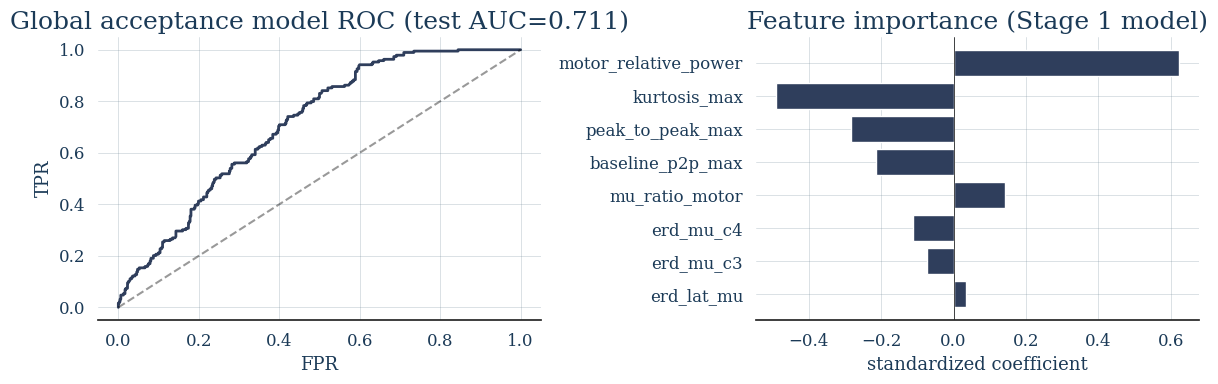

In [76]:
# Per-source rejection rates and feature importances on the test split.
src_te   = src_type[idx_te]
pred_te  = accept_model.predict(F_te_s)
p_te_arr = p_te

print("Per-source behaviour on test set:")
print(f"  {'group':22s}  {'n':>4s}  {'P(accept)':>10s}  {'rejected':>10s}")
for grp in ["clean_good", "clean_borderline",
             "artifact", "disengagement", "implausibility", "snr", "borderline"]:
    mask = src_te == grp
    if not mask.any():
        continue
    n     = int(mask.sum())
    p_m   = float(p_te_arr[mask].mean())
    rej   = int((pred_te[mask] == 0).sum())
    print(f"  {grp:22s}  {n:4d}  {p_m:10.3f}  {rej:>4d}/{n}")

coefs = accept_model.coef_[0]
order = np.argsort(np.abs(coefs))[::-1]
print("\nStandardized feature importance (|coef|, + = toward accept):")
for j in order:
    print(f"  {rqe.feature_names[j]:24s}  coef={coefs[j]:+.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fpr, tpr, _ = roc_curve(Y_te, p_te)
ax[0].plot(fpr, tpr, lw=2)
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
ax[0].set(xlabel="FPR", ylabel="TPR",
          title=f"Global acceptance model ROC (test AUC={roc_auc_score(Y_te, p_te):.3f})")
ax[1].barh([rqe.feature_names[j] for j in order[::-1]], coefs[order[::-1]])
ax[1].axvline(0, color="k", lw=0.5)
ax[1].set(xlabel="standardized coefficient", title="Feature importance (Stage 1 model)")
fig.tight_layout()
plt.show()

---
## Stage 2 — Per-Subject Calibration & Inference

Subject 9 is the held-out test subject. The frozen global acceptance model
gates each trial **before** any subject-specific model sees it.

**Calibration flow:**
1. Stream calibration pool through frozen acceptance model → accepted buffer
2. Once `min_per_class` accepted trials per class accumulate, fit CSP + LDA
3. Adaptive stopping decides when calibration is sufficient
4. CSP + LDA frozen after calibration

**Inference flow:**
Each new trial → acceptance gate (raw quality, frozen global model) → if accepted → CSP + LDA → prediction

In [77]:
x9, y9, metadata9 = paradigm.get_data(dataset, subjects=[HELD_OUT_SUBJECT])

# Session 1 (index 0train): calibration pool
# Session 2 (index 1test):  held-out evaluation
x9_cal_pool = x9[0:144]
y9_cal_pool = y9[0:144]
x9_eval     = x9[144:288]
y9_eval     = y9[144:288]

# Alias for Layer 6/7 cells (expected variable name)
x_eval       = x9_eval
y_eval       = y9_eval
x_eval_holdout = x9_eval
y_eval_holdout = y9_eval

print(f"Subject {HELD_OUT_SUBJECT} loaded: {x9.shape[0]} trials total")
print(f"  Calibration pool : {x9_cal_pool.shape[0]} trials  "
      f"(classes: {Counter(y9_cal_pool)})")
print(f"  Evaluation session: {x9_eval.shape[0]} trials  "
      f"(classes: {Counter(y9_eval)})")

Subject 2 loaded: 288 trials total
  Calibration pool : 144 trials  (classes: Counter({np.str_('left_hand'): 72, np.str_('right_hand'): 72}))
  Evaluation session: 144 trials  (classes: Counter({np.str_('left_hand'): 72, np.str_('right_hand'): 72}))


In [78]:
# # Gate calibration pool through the frozen global acceptance model.
# # Only accepted trials proceed to CSP+LDA fitting.
# MIN_PER_CLASS = 10   # minimum accepted trials per class before fitting CSP+LDA

# F_cal_pool = rqe.extract_many(x9_cal_pool)
# F_cal_s    = accept_scaler.transform(F_cal_pool)
# p_cal      = accept_model.predict_proba(F_cal_s)[:, 1]
# gate_mask  = p_cal >= 0.5

# x_cal_accepted = x9_cal_pool[gate_mask]
# y_cal_accepted = y9_cal_pool[gate_mask]

# classes_acc, counts_acc = np.unique(y_cal_accepted, return_counts=True)

# print(f"Calibration pool : {len(x9_cal_pool)} trials")
# print(f"Accepted by gate : {gate_mask.sum()} ({100*gate_mask.mean():.1f}%)")
# print(f"Rejected by gate : {(~gate_mask).sum()}")
# print(f"Accepted class distribution: {dict(zip(classes_acc, counts_acc))}")

# if min(counts_acc) < MIN_PER_CLASS:
#     print(f"\nWARNING: Only {min(counts_acc)} accepted trials in the minority class "
#           f"(< {MIN_PER_CLASS}). Using all accepted trials for calibration.")

# Gate calibration pool through the frozen global acceptance model.
# Strategy: accept the top (100 - CAL_ACCEPT_PERCENTILE)% of trials ranked
# by P(accept). This is subject-adaptive — even a hard subject always
# provides enough calibration data. Trial quality ranking is preserved;
# we just remove the fixed cross-subject probability cutoff.
MIN_PER_CLASS         = 10    # min accepted trials per class before fitting CSP+LDA
CAL_ACCEPT_PERCENTILE = 30    # reject bottom 30% -> top 70% accepted

F_cal_pool    = rqe.extract_many(x9_cal_pool)
F_cal_s       = accept_scaler.transform(F_cal_pool)
p_cal         = accept_model.predict_proba(F_cal_s)[:, 1]

cal_threshold = np.percentile(p_cal, CAL_ACCEPT_PERCENTILE)
gate_mask     = p_cal >= cal_threshold

x_cal_accepted = x9_cal_pool[gate_mask]
y_cal_accepted = y9_cal_pool[gate_mask]

classes_acc, counts_acc = np.unique(y_cal_accepted, return_counts=True)

print(f"Calibration pool  : {len(x9_cal_pool)} trials")
print(f"Acceptance cutoff : P(accept) >= {cal_threshold:.3f}  (top-{100 - CAL_ACCEPT_PERCENTILE}% subject-adaptive)")
print(f"Accepted by gate  : {gate_mask.sum()} ({100 * gate_mask.mean():.1f}%)")
print(f"Rejected by gate  : {(~gate_mask).sum()}")
print(f"Accepted class distribution: {dict(zip(classes_acc, counts_acc))}")

if min(counts_acc) < MIN_PER_CLASS:
    print(f"\nWARNING: Only {min(counts_acc)} accepted trials in the minority class "
          f"(< {MIN_PER_CLASS}). Consider lowering CAL_ACCEPT_PERCENTILE.")

Calibration pool  : 144 trials
Acceptance cutoff : P(accept) >= 0.670  (top-70% subject-adaptive)
Accepted by gate  : 101 (70.1%)
Rejected by gate  : 43
Accepted class distribution: {np.str_('left_hand'): np.int64(51), np.str_('right_hand'): np.int64(50)}


In [79]:
# Adaptive calibration stopping on the accepted (already gated) trial pool.
# The stopping logic uses a lightweight CSP+LDA loop — no acceptance model
# is consulted here; quality filtering happened at the gate step above.

if min(counts_acc) >= MIN_PER_CLASS and len(x_cal_accepted) >= 60:
    calib_end_idx, calib_history = _adaptive_calibration_stop(
        x_cal_accepted, y_cal_accepted,
        min_trials=48, step=12, max_trials=132,
        patience=2, eps_acc=0.005, eps_conf=0.005,
    )
    x_train = x_cal_accepted[:calib_end_idx]
    y_train = y_cal_accepted[:calib_end_idx]
    print(f"Adaptive stopping selected {calib_end_idx} calibration trials.")
    print("Calibration history:")
    for h in calib_history:
        print(f"  n={h['n_cal']:3d}  val_acc={h['val_acc']:.3f}  "
              f"val_conf={h['val_conf']:.3f}  n_val={h['n_val']}")
else:
    x_train = x_cal_accepted
    y_train = y_cal_accepted
    calib_end_idx  = len(x_train)
    calib_history  = []
    print(f"Skipped adaptive stopping (too few accepted trials). "
          f"Using all {len(x_train)} accepted trials.")

# Remaining accepted calibration trials (post-calibration validation pool)
x_test = x_cal_accepted[calib_end_idx:]
y_test = y_cal_accepted[calib_end_idx:]
print(f"\nCalibration trials : {len(x_train)}")
print(f"Post-cal val pool  : {len(x_test)}")

Computing rank from data with rank=None
    Using tolerance 24 (2.2e-16 eps * 22 dim * 4.9e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 27 (2.2e-16 eps * 22 dim * 5.5e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 29 (2.2e-16 eps * 22 dim * 6e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=left_

In [80]:
# Fit CSP + LDA on accepted calibration trials only.
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
x_csp_train = csp.fit_transform(task_view(x_train), y_train)

ld = LDA()
ld.fit(x_csp_train, y_train)

# In-sample calibration check
print("In-sample calibration performance (accepted trials only):")
print(classification_report(y_train, ld.predict(x_csp_train)))

# Held-out eval session (no acceptance gate applied here — evaluating raw CSP+LDA)
x_csp_eval = csp.transform(task_view(x9_eval))
y_pred_eval = ld.predict(x_csp_eval)
print("Eval session performance (raw CSP+LDA, no gate):")
print(classification_report(y9_eval, y_pred_eval))

Computing rank from data with rank=None


    Using tolerance 32 (2.2e-16 eps * 22 dim * 6.5e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
In-sample calibration performance (accepted trials only):
              precision    recall  f1-score   support

   left_hand       0.88      0.84      0.86        44
  right_hand       0.83      0.88      0.85        40

    accuracy                           0.86        84
   macro avg       0.86      0.86      0.86        84
weighted avg       0.86      0.86      0.86        84

Eval session performance (raw CSP+LDA, no gate):
              precision    recall  f1-score   support

   left_hand       0.56      0.57      0.57        72
  right_hand       0.56      0.56      0.56        72

    accuracy                           0.56       144
   macro avg       0.

In [81]:
# FeatureExtractor: 15-d features including CSP/LDA outputs.
# Used for Layer 7 session-level analysis after CSP+LDA are calibrated.
# NOT used for the acceptance gate (rqe handles that).
fe = FeatureExtractor(
    csp=csp, lda=ld, ch_names=ch_names, sfreq=sfreq,
).fit(x_train, y_train)

print("FeatureExtractor fitted. Feature names:")
for name in fe.feature_names:
    print(f"  {name}")

FeatureExtractor fitted. Feature names:
  lda_margin
  lda_proba_max
  csp_logvar_0
  csp_logvar_1
  csp_logvar_2
  csp_logvar_3
  mahal_to_predicted
  peak_to_peak_max
  kurtosis_max
  erd_mu_c3
  erd_mu_c4
  erd_lat_mu
  mu_ratio_motor
  motor_relative_power
  baseline_p2p_max


Computing rank from data with rank=None
    Using tolerance 16 (2.2e-16 eps * 22 dim * 3.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 16 (2.2e-16 eps * 22 dim * 3.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 17 (2.2e-16 eps * 22 dim * 3.4e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=lef

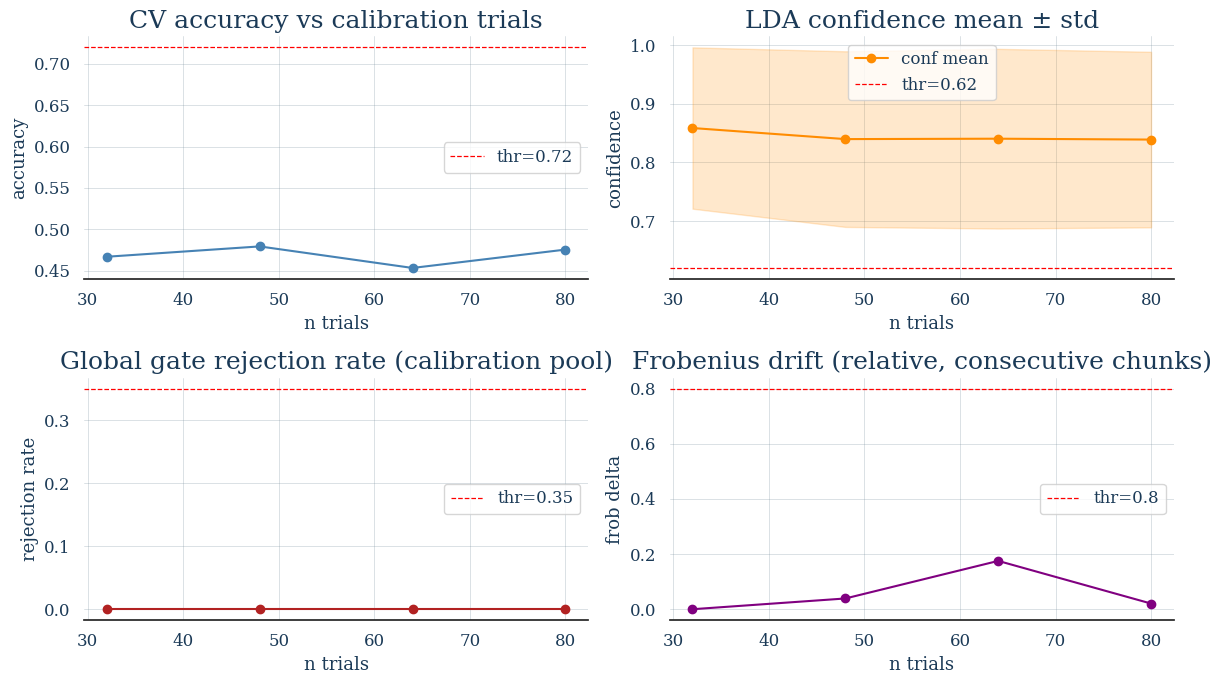

In [82]:
@dataclass
class CalibrationChunkMetrics:
    chunk_end:       int
    n_trials:        int
    cv_accuracy:     float
    conf_mean:       float
    conf_std:        float
    reject_rate:     float
    frob_delta:      float
    passed:          bool
    failed_criteria: List[str] = field(default_factory=list)


@dataclass
class CalibrationStopConfig:
    chunk_size:       int   = 16
    min_trials:       int   = 32
    patience:         int   = 2
    acc_thr:          float = 0.72
    conf_mean_thr:    float = 0.62
    conf_std_thr:     float = 0.14
    reject_rate_thr:  float = 0.35
    frob_delta_thr:   float = 0.80


def evaluate_calibration_chunk(
    X_pool: np.ndarray,
    y_pool: np.ndarray,
    fe,                     # FeatureExtractor (CSP+LDA required for confidence)
    rqe_,                   # RawQualityExtractor (for rejection rate, no CSP/LDA)
    accept_model_,          # frozen global acceptance model
    accept_scaler_,         # frozen global scaler
    prev_mean_cov: Optional[np.ndarray],
    cfg: CalibrationStopConfig,
) -> Tuple[CalibrationChunkMetrics, np.ndarray]:
    n = len(X_pool)

    # Criterion 1: CV accuracy
    cv_pipe = Pipeline([
        ("csp", CSP_cls(n_components=4, reg=None, log=True, norm_trace=False)),
        ("lda", LDA_cls()),
    ])
    cv_scores = cross_val_score(
        cv_pipe, task_view(X_pool), y_pool,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=0),
        scoring="accuracy",
    )
    cv_acc = float(cv_scores.mean())

    # Criterion 2 & 3: LDA confidence mean / std from full FeatureExtractor
    F_full    = fe.extract_many(X_pool)
    conf_vals = F_full[:, fe.feature_names.index("lda_proba_max")]
    conf_mean = float(conf_vals.mean())
    conf_std  = float(conf_vals.std())

    # Criterion 4: rejection rate from the frozen global acceptance model
    F_raw   = rqe_.extract_many(X_pool)
    F_raw_s = accept_scaler_.transform(F_raw)
    p_acc   = accept_model_.predict_proba(F_raw_s)[:, 1]
    reject_rate = float((p_acc < 0.5).mean())

    # Criterion 5: Frobenius drift between consecutive chunks
    cur_cov = np.mean(
        np.stack([np.cov(ep[..., BASELINE_SAMPLES:]) for ep in X_pool[-cfg.chunk_size:]]),
        axis=0,
    )
    if prev_mean_cov is None:
        frob_delta = 0.0
    else:
        prev_norm = np.linalg.norm(prev_mean_cov, ord="fro") + 1e-12
        frob_delta = float(np.linalg.norm(cur_cov - prev_mean_cov, ord="fro") / prev_norm)

    failed = []
    if cv_acc     < cfg.acc_thr:          failed.append(f"acc={cv_acc:.3f}<{cfg.acc_thr}")
    if conf_mean  < cfg.conf_mean_thr:    failed.append(f"conf_mean={conf_mean:.3f}")
    if conf_std   > cfg.conf_std_thr:     failed.append(f"conf_std={conf_std:.3f}")
    if reject_rate > cfg.reject_rate_thr: failed.append(f"reject_rate={reject_rate:.3f}")
    if frob_delta  > cfg.frob_delta_thr:  failed.append(f"frob_delta={frob_delta:.3f}")

    metrics = CalibrationChunkMetrics(
        chunk_end=n, n_trials=n,
        cv_accuracy=cv_acc, conf_mean=conf_mean, conf_std=conf_std,
        reject_rate=reject_rate, frob_delta=frob_delta,
        passed=(len(failed) == 0), failed_criteria=failed,
    )
    return metrics, cur_cov


def run_calibration_stop_controller(
    X_pool, y_pool, fe, rqe_, accept_model_, accept_scaler_,
    cfg: Optional[CalibrationStopConfig] = None,
):
    if cfg is None:
        cfg = CalibrationStopConfig()

    history: List[CalibrationChunkMetrics] = []
    prev_cov = None
    patience_count = 0
    stop_at = None

    for end in range(cfg.min_trials, len(X_pool) + 1, cfg.chunk_size):
        if end > len(X_pool):
            end = len(X_pool)

        metrics, cur_cov = evaluate_calibration_chunk(
            X_pool[:end], y_pool[:end],
            fe, rqe_, accept_model_, accept_scaler_, prev_cov, cfg,
        )
        history.append(metrics)
        prev_cov = cur_cov

        if metrics.passed:
            patience_count += 1
        else:
            patience_count = 0

        if patience_count >= cfg.patience:
            stop_at = end
            break

    return stop_at, history

# Run the calibration stop controller on the accepted calibration trials.
cfg = CalibrationStopConfig()

if len(x_train) >= cfg.min_trials:
    stop_at, cal_history = run_calibration_stop_controller(
        x_train, y_train, fe, rqe, accept_model, accept_scaler, cfg,
    )
    print(f"Controller stopped at trial {stop_at} "
          f"({'early stop' if stop_at and stop_at < len(x_train) else 'used all'})")
    print(f"\n{'n':>5s}  {'cv_acc':>7s}  {'conf_mean':>9s}  {'conf_std':>8s}  "
          f"{'rej_rate':>8s}  {'frob':>6s}  {'pass'}")
    for m in cal_history:
        ok = "PASS" if m.passed else "FAIL"
        print(f"{m.n_trials:5d}  {m.cv_accuracy:7.3f}  {m.conf_mean:9.3f}  "
              f"{m.conf_std:8.3f}  {m.reject_rate:8.3f}  {m.frob_delta:6.3f}  {ok}")
        if m.failed_criteria:
            print(f"       failed: {m.failed_criteria}")
else:
    cal_history = []
    stop_at = None
    print(f"Skipped: only {len(x_train)} accepted calibration trials < min={cfg.min_trials}")


if cal_history:
    ns     = [m.n_trials    for m in cal_history]
    cv_acc = [m.cv_accuracy for m in cal_history]
    c_mean = [m.conf_mean   for m in cal_history]
    c_std  = [m.conf_std    for m in cal_history]
    rej    = [m.reject_rate for m in cal_history]
    frob   = [m.frob_delta  for m in cal_history]

    fig, axs = plt.subplots(2, 2, figsize=(12, 7))
    axs = axs.flatten()

    axs[0].plot(ns, cv_acc, "o-", color="steelblue")
    axs[0].axhline(cfg.acc_thr, color="red", ls="--", lw=0.9, label=f"thr={cfg.acc_thr}")
    axs[0].set_title("CV accuracy vs calibration trials")
    axs[0].set_xlabel("n trials"); axs[0].set_ylabel("accuracy")
    axs[0].legend(); axs[0].grid(alpha=0.3)

    c_mean_arr = np.array(c_mean); c_std_arr = np.array(c_std)
    axs[1].plot(ns, c_mean_arr, "o-", color="darkorange", label="conf mean")
    axs[1].fill_between(ns, c_mean_arr - c_std_arr, c_mean_arr + c_std_arr,
                        alpha=0.2, color="darkorange")
    axs[1].axhline(cfg.conf_mean_thr, color="red", ls="--", lw=0.9,
                   label=f"thr={cfg.conf_mean_thr}")
    axs[1].set_title("LDA confidence mean ± std")
    axs[1].set_xlabel("n trials"); axs[1].set_ylabel("confidence")
    axs[1].legend(); axs[1].grid(alpha=0.3)

    axs[2].plot(ns, rej, "o-", color="firebrick")
    axs[2].axhline(cfg.reject_rate_thr, color="red", ls="--", lw=0.9,
                   label=f"thr={cfg.reject_rate_thr}")
    axs[2].set_title("Global gate rejection rate (calibration pool)")
    axs[2].set_xlabel("n trials"); axs[2].set_ylabel("rejection rate")
    axs[2].legend(); axs[2].grid(alpha=0.3)

    axs[3].plot(ns, frob, "o-", color="purple")
    axs[3].axhline(cfg.frob_delta_thr, color="red", ls="--", lw=0.9,
                   label=f"thr={cfg.frob_delta_thr}")
    axs[3].set_title("Frobenius drift (relative, consecutive chunks)")
    axs[3].set_xlabel("n trials"); axs[3].set_ylabel("frob delta")
    axs[3].legend(); axs[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [83]:
# Spectral analysis on all subject-9 trials: fatigue and engagement indices.
psds, freqs = psd_array_welch(x9, sfreq=sfreq, fmin=1, fmax=40, n_fft=256)
print(f"PSD shape: {psds.shape}   freq bins: {len(freqs)}")

theta_band = (4, 8)
alpha_band = (8, 13)
beta_band  = (13, 30)

theta_mask = (freqs >= theta_band[0]) & (freqs <= theta_band[1])
alpha_mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
beta_mask  = (freqs >= beta_band[0]) & (freqs <= beta_band[1])

stress_channels = ["Fz", "FC1", "FC2"]
fatigue_channels = ["Pz", "POz"]
engage_channels  = ["C3", "Cz", "C4"]

stress_idx  = [ch_names.index(c) for c in stress_channels]
fatigue_idx = [ch_names.index(c) for c in fatigue_channels]
engage_idx  = [ch_names.index(c) for c in engage_channels]

theta_power = psds[:, fatigue_idx][:, :, theta_mask].mean(axis=(1, 2))
alpha_power = psds[:, fatigue_idx][:, :, alpha_mask].mean(axis=(1, 2))
beta_power  = psds[:, engage_idx][:, :, beta_mask].mean(axis=(1, 2))

fatigue          = theta_power / beta_power
engagement_index = beta_power / (alpha_power + theta_power + 1e-8)

print("\nFatigue index samples — calibration pool:")
for i in [0, 70, 143]:
    print(f"  trial {i:3d}: fatigue={fatigue[i]:.4f}  engagement={engagement_index[i]:.4f}")
print("\nFatigue index samples — eval session:")
for i in [144, 214, 287]:
    print(f"  trial {i:3d}: fatigue={fatigue[i]:.4f}  engagement={engagement_index[i]:.4f}")

Effective window size : 1.024 (s)
PSD shape: (288, 22, 39)   freq bins: 39

Fatigue index samples — calibration pool:
  trial   0: fatigue=0.0303  engagement=1.4916
  trial  70: fatigue=0.3152  engagement=0.1671
  trial 143: fatigue=0.1562  engagement=0.5323

Fatigue index samples — eval session:
  trial 144: fatigue=0.0333  engagement=0.7449
  trial 214: fatigue=0.0549  engagement=1.0699
  trial 287: fatigue=0.2762  engagement=0.1938


In [84]:
# ── Pseudo-online trial engine ────────────────────────────────────────────
# The engine uses the FROZEN GLOBAL acceptance model (rqe + accept_scaler +
# accept_model) as the gate. Only accepted trials are classified by CSP+LDA.
# Rejection reasons are derived from raw quality features only.

@dataclass
class TrialResult:
    trial_idx:      int
    y_true:         str
    y_pred:         str
    correct:        bool
    confidence:     float
    margin:         float
    accepted:       bool
    reject_reasons: List[str] = field(default_factory=list)
    timestamp_s:    float = 0.0


def _rejection_reasons(
    feat_vec, feat_names,
    p2p_thr=150e-6, kurt_thr=5.0, erd_lat_thr=0.05, base_p2p_thr=120e-6,
) -> List[str]:
    """Return rejection reason flags from an 8-d raw-quality feature vector."""
    idx = {n: i for i, n in enumerate(feat_names)}
    reasons = []
    if feat_vec[idx["peak_to_peak_max"]] > p2p_thr:
        reasons.append(f"artifact_p2p({feat_vec[idx['peak_to_peak_max']]*1e6:.0f}uV)")
    if feat_vec[idx["kurtosis_max"]] > kurt_thr:
        reasons.append(f"artifact_kurt({feat_vec[idx['kurtosis_max']]:.1f})")
    if abs(feat_vec[idx["erd_lat_mu"]]) < erd_lat_thr:
        reasons.append(f"weak_lateralization({abs(feat_vec[idx['erd_lat_mu']]):.3f})")
    if feat_vec[idx["baseline_p2p_max"]] > base_p2p_thr:
        reasons.append("noisy_baseline")
    return reasons


def pseudo_online_engine(
    csp, lda_model, raw_extractor, accept_model, accept_scaler,
    X, y,
    accept_threshold: float = 0.5,
    speed_factor: float = 0.0,
    verbose: bool = True,
) -> List[TrialResult]:
    """
    Causal trial-by-trial simulation engine.

    Per trial:
      1. Raw quality features extracted and scored by the frozen global
         acceptance model — gate decision is made using raw-EEG features only.
      2. If accepted: classified by the subject-calibrated CSP + LDA.
      3. If rejected: rejection reasons derived from raw quality features.

    With speed_factor=0.0 output exactly matches a batch forward pass
    on the same data (verified by the offline-equivalence check below).
    """
    results: List[TrialResult] = []
    t_sim = 0.0

    for i in range(len(X)):
        epoch = X[i:i + 1]

        # --- decode (always run, even for rejected trials) ---
        x_csp_i   = csp.transform(task_view(epoch))
        pred_arr  = lda_model.predict(x_csp_i)
        proba_arr = lda_model.predict_proba(x_csp_i)
        margin_val = float(abs(lda_model.decision_function(x_csp_i)[0]))

        y_pred_i    = str(pred_arr[0])
        confidence_i = float(proba_arr[0].max())

        # --- acceptance gate: raw quality features only ---
        feat_raw = raw_extractor.extract(epoch[0])
        feat_s   = accept_scaler.transform(feat_raw.reshape(1, -1))
        p_acc    = float(accept_model.predict_proba(feat_s)[0, 1])
        accepted_i = p_acc >= accept_threshold

        reasons: List[str] = []
        if not accepted_i:
            reasons = _rejection_reasons(feat_raw, raw_extractor.feature_names)

        t_sim += CLASSIFICATION_DELAY_S
        if speed_factor > 0:
            time.sleep(CLASSIFICATION_DELAY_S * speed_factor)

        result = TrialResult(
            trial_idx      = i,
            y_true         = str(y[i]),
            y_pred         = y_pred_i,
            correct        = (y_pred_i == str(y[i])),
            confidence     = confidence_i,
            margin         = margin_val,
            accepted       = accepted_i,
            reject_reasons = reasons,
            timestamp_s    = t_sim,
        )
        results.append(result)

        if verbose and i % 20 == 0:
            gate_str = "ACCEPT" if accepted_i else "REJECT"
            print(f"  [{i:3d}] true={str(y[i]):<12s} pred={y_pred_i:<12s} "
                  f"conf={confidence_i:.2f} gate={gate_str}")

    return results

In [85]:
# Deploy: pseudo-online simulation on held-out eval session.
print("Pseudo-online simulation — Subject", HELD_OUT_SUBJECT, "eval session\n")
print(f"Using frozen deployment gate threshold from calibration: {cal_threshold:.3f}")
engine_results = pseudo_online_engine(
    csp, ld, rqe, accept_model, accept_scaler,
    x9_eval, y9_eval,
    accept_threshold=cal_threshold,
    speed_factor=0.0,
    verbose=True,
)

n_trials  = len(engine_results)
n_acc     = sum(r.accepted for r in engine_results)
n_rej     = n_trials - n_acc
acc_all   = sum(r.correct for r in engine_results) / n_trials
acc_gated = (sum(r.correct for r in engine_results if r.accepted) / n_acc
             if n_acc else float("nan"))

print(f"\n{'='*55}")
print(f"  Trials        : {n_trials}")
print(f"  Accepted      : {n_acc}  ({100*n_acc/n_trials:.0f}%)")
print(f"  Rejected      : {n_rej}  ({100*n_rej/n_trials:.0f}%)")
print(f"  Accuracy (all): {acc_all:.3f}")
print(f"  Accuracy (acc): {acc_gated:.3f}")

all_reasons = [r for res in engine_results for r in res.reject_reasons]
if all_reasons:
    print("\n  Rejection reason breakdown:")
    for reason, cnt in Counter(r.split("(")[0] for r in all_reasons).most_common():
        print(f"    {reason:<28s}: {cnt}")

# Offline/online equivalence check
offline_preds     = ld.predict(csp.transform(task_view(x9_eval)))
online_preds      = np.array([r.y_pred for r in engine_results])
offline_preds_str = np.array([str(p) for p in offline_preds])
match = np.all(online_preds == offline_preds_str)
print(f"\n  Offline/online pred match: {match}  "
      f"({'PASS' if match else 'FAIL — check engine'})")

Pseudo-online simulation — Subject 2 eval session

Using frozen deployment gate threshold from calibration: 0.670
  [  0] true=left_hand    pred=right_hand   conf=0.86 gate=REJECT
  [ 20] true=right_hand   pred=right_hand   conf=0.96 gate=ACCEPT
  [ 40] true=right_hand   pred=right_hand   conf=0.72 gate=REJECT
  [ 60] true=left_hand    pred=left_hand    conf=0.51 gate=REJECT
  [ 80] true=left_hand    pred=right_hand   conf=0.99 gate=REJECT
  [100] true=left_hand    pred=left_hand    conf=0.94 gate=REJECT
  [120] true=left_hand    pred=left_hand    conf=1.00 gate=REJECT
  [140] true=left_hand    pred=left_hand    conf=0.92 gate=ACCEPT

  Trials        : 144
  Accepted      : 44  (31%)
  Rejected      : 100  (69%)
  Accuracy (all): 0.562
  Accuracy (acc): 0.500

  Rejection reason breakdown:
    artifact_p2p                : 100
    noisy_baseline              : 100
    weak_lateralization         : 14

  Offline/online pred match: True  (PASS)


In [86]:
# Gate-quality analysis: does the acceptance model concentrate rejections
# on trials the CSP+LDA would get wrong anyway?
y_pred_eval_arr = ld.predict(csp.transform(task_view(x9_eval)))
lda_correct     = y9_eval == y_pred_eval_arr

F_eval   = rqe.extract_many(x9_eval)
F_eval_s = accept_scaler.transform(F_eval)
p_eval   = accept_model.predict_proba(F_eval_s)[:, 1]
accepted = p_eval >= cal_threshold

n     = len(x9_eval)
n_acc_e = int(accepted.sum())
n_rej_e = n - n_acc_e
acc_g = accuracy_score(y9_eval[accepted],  y_pred_eval_arr[accepted])  if n_acc_e > 0 else float("nan")
acc_r = accuracy_score(y9_eval[~accepted], y_pred_eval_arr[~accepted]) if n_rej_e > 0 else float("nan")

print(f"Eval session trials              : {n}")
print(f"Raw LDA accuracy                 : {accuracy_score(y9_eval, y_pred_eval_arr):.3f}")
print(f"Acceptance rate                  : {n_acc_e}/{n} ({100*n_acc_e/n:.1f}%)")
print(f"LDA accuracy on ACCEPTED trials  : {acc_g:.3f}   (n={n_acc_e})")
print(f"LDA accuracy on REJECTED trials  : {acc_r:.3f}   (n={n_rej_e})")
print(f"Mean P(accept)                   : {p_eval.mean():.3f}")

print("\nAcceptance vs LDA correctness:")
print(f"  accepted & LDA correct    : {int((accepted &  lda_correct).sum())}")
print(f"  accepted & LDA wrong      : {int((accepted & ~lda_correct).sum())}")
print(f"  rejected & LDA correct    : {int((~accepted &  lda_correct).sum())}  <- false rejects")
print(f"  rejected & LDA wrong      : {int((~accepted & ~lda_correct).sum())}  <- correctly caught")

Eval session trials              : 144
Raw LDA accuracy                 : 0.562
Acceptance rate                  : 44/144 (30.6%)
LDA accuracy on ACCEPTED trials  : 0.500   (n=44)
LDA accuracy on REJECTED trials  : 0.590   (n=100)
Mean P(accept)                   : 0.577

Acceptance vs LDA correctness:
  accepted & LDA correct    : 22
  accepted & LDA wrong      : 22
  rejected & LDA correct    : 59  <- false rejects
  rejected & LDA wrong      : 41  <- correctly caught


In [87]:
# Corrupt-and-catch test: apply CorruptionEngine to the eval session
# (which the global model has never seen) and check per-family catch rates.
engine_eval = CorruptionEngine(
    sfreq=sfreq, baseline_samples=BASELINE_SAMPLES, seed=99,
)
X_bad_eval, bad_meta_eval = engine_eval.generate_dataset(x9_eval, n_per_epoch=3)

F_bad_eval   = rqe.extract_many(X_bad_eval)
F_bad_eval_s = accept_scaler.transform(F_bad_eval)
p_bad_eval   = accept_model.predict_proba(F_bad_eval_s)[:, 1]
pred_bad     = (p_bad_eval >= 0.5).astype(int)

bad_fam_eval = np.array([m["family"]     for m in bad_meta_eval])

print(f"Corrupt-and-catch: {len(X_bad_eval)} corrupted eval trials\n")
print("Per-family rejection rate (eval session, never seen during training):")
print(f"  {'family':16s} {'n':>4s}  {'P(accept)':>10s}  rejected")
for fam in ["artifact", "disengagement", "implausibility", "snr", "borderline"]:
    mask = bad_fam_eval == fam
    n = int(mask.sum())
    if n == 0:
        continue
    rej   = int((pred_bad[mask] == 0).sum())
    p_mean = float(p_bad_eval[mask].mean())
    print(f"  {fam:16s} {n:4d}  {p_mean:10.3f}  {rej}/{n} ({100*rej/n:.0f}%)")

print(f"\nOverall: {int((pred_bad == 0).sum())}/{len(pred_bad)} "
      f"({100*(pred_bad == 0).mean():.0f}%) rejected")

Corrupt-and-catch: 432 corrupted eval trials

Per-family rejection rate (eval session, never seen during training):
  family              n   P(accept)  rejected
  artifact          101       0.507  38/101 (38%)
  disengagement     179       0.462  84/179 (47%)
  implausibility     50       0.510  22/50 (44%)
  snr                41       0.517  16/41 (39%)
  borderline         61       0.489  26/61 (43%)

Overall: 186/432 (43%) rejected


---
## Stage 3 — Longitudinal Analysis

### Layer 6 — Controlled Degradation Model

A synthetic longitudinal series is built from the clean eval session by applying
deterministic `r`-parameterized transforms at the session level.  
`r ∈ [0, 1]` (1.0 = pristine, 0.0 = maximally degraded).

Four transforms act **only on the imagery window** (rest baseline stays clean):
- ERD amplitude scaling: `α(r) = 0.5 + 0.5·r`
- Lateralization mixing of C3/C4: `β(r) = 0.4·(1−r)`
- Spatially correlated in-band noise: `γ(r) = 2·(1−r)`
- Trial timing jitter: `δ(r) = 50·(1−r)` ms

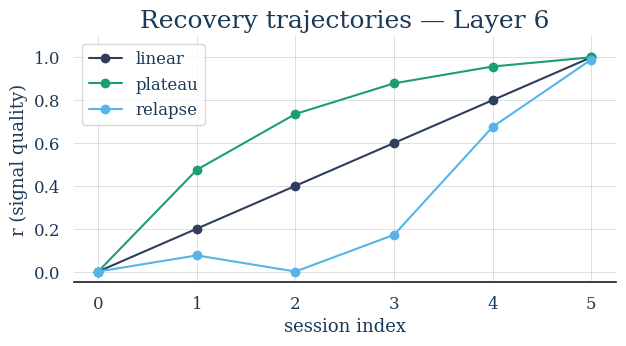

In [88]:
degr      = DegradationModel(sfreq=sfreq, baseline_samples=BASELINE_SAMPLES, seed=42)
n_sessions = 6
shapes     = ["linear", "plateau", "relapse"]

fig, ax = plt.subplots(1, 1, figsize=(7, 3.2))
for shape in shapes:
    rs = degr.build_trajectory(n_sessions, shape=shape)
    ax.plot(np.arange(n_sessions), rs, marker="o", label=shape)
ax.set_xlabel("session index")
ax.set_ylabel("r (signal quality)")
ax.set_ylim(-0.05, 1.1)
ax.set_title("Recovery trajectories — Layer 6")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

    r  lda_acc   erd_c3   erd_c4    |lat|   conf
 1.00    0.562   -0.413   -0.546    0.355  0.836
 0.80    0.465   -0.153   -0.226    0.277  0.936
 0.60    0.500    0.056    0.028    0.232  0.957
 0.40    0.500    0.216    0.230    0.203  0.978
 0.20    0.493    0.315    0.370    0.243  0.978
 0.00    0.493    0.353    0.462    0.333  0.985


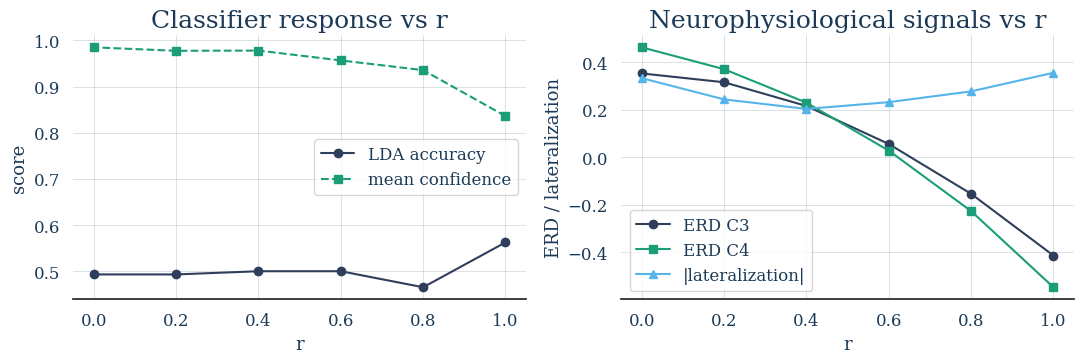

In [89]:
# Sanity check: as r decreases, motor-cortex ERD weakens, lateralization
# gap shrinks, LDA confidence drops, and raw accuracy falls.
r_grid = np.array([1.0, 0.8, 0.6, 0.4, 0.2, 0.0])
rows = []
for r in r_grid:
    degr_local = DegradationModel(
        sfreq=sfreq, baseline_samples=BASELINE_SAMPLES,
        seed=int(round(r * 100)),
    )
    X_deg = degr_local.degrade_session(x_eval, float(r), jitter=True)
    acc   = accuracy_score(y_eval, ld.predict(csp.transform(task_view(X_deg))))

    F = fe.extract_many(X_deg)
    erd_c3  = float(np.mean(F[:, fe.feature_names.index("erd_mu_c3")]))
    erd_c4  = float(np.mean(F[:, fe.feature_names.index("erd_mu_c4")]))
    erd_lat = float(np.mean(np.abs(F[:, fe.feature_names.index("erd_lat_mu")])))
    conf    = float(np.mean(F[:, fe.feature_names.index("lda_proba_max")]))
    rows.append((float(r), acc, erd_c3, erd_c4, erd_lat, conf))

print(f"{'r':>5s} {'lda_acc':>8s} {'erd_c3':>8s} {'erd_c4':>8s} {'|lat|':>8s} {'conf':>6s}")
for r, acc, e3, e4, el, c in rows:
    print(f"{r:5.2f} {acc:8.3f} {e3:8.3f} {e4:8.3f} {el:8.3f} {c:6.3f}")

arr = np.array(rows)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(arr[:, 0], arr[:, 1], "o-", label="LDA accuracy")
ax[0].plot(arr[:, 0], arr[:, 5], "s--", label="mean confidence")
ax[0].set_xlabel("r"); ax[0].set_ylabel("score")
ax[0].grid(alpha=0.3); ax[0].legend()
ax[0].set_title("Classifier response vs r")
ax[1].plot(arr[:, 0], arr[:, 2], "o-", label="ERD C3")
ax[1].plot(arr[:, 0], arr[:, 3], "s-", label="ERD C4")
ax[1].plot(arr[:, 0], arr[:, 4], "^-", label="|lateralization|")
ax[1].set_xlabel("r"); ax[1].set_ylabel("ERD / lateralization")
ax[1].grid(alpha=0.3); ax[1].legend()
ax[1].set_title("Neurophysiological signals vs r")
plt.tight_layout()
plt.show()

### Layer 7 — Longitudinal Feature Vector & Analysis

Per session: collapse per-trial features into a fixed-length session vector,
then regress the unknown `r`, cluster sessions into recovery stages, and
drive an assistance-level simulation.

In [90]:
def session_feature_vector(X_session, y_session, csp, ld, fe, baseline_cov=None):
    """Collapse a session of trials into one fixed-length feature vector.

    Uses the per-trial 15-d FeatureExtractor output and adds three
    session-level quantities: raw LDA accuracy, Frobenius drift from
    a reference covariance, and inter-trial covariance variance.
    """
    F     = fe.extract_many(X_session)
    names = fe.feature_names

    def col(name):
        return F[:, names.index(name)]

    X_task = X_session[..., fe.baseline_samples:]
    covs   = np.array([np.cov(epoch) for epoch in X_task])
    mean_cov = covs.mean(axis=0)
    intertrial_cov_var = float(np.mean(np.var(covs, axis=0)))

    frob = 0.0 if baseline_cov is None else float(
        np.linalg.norm(mean_cov - baseline_cov, ord="fro")
    )

    y_pred = ld.predict(csp.transform(X_task))
    acc    = float(np.mean(y_pred == y_session))

    feats = {
        "erd_mu_c3_mean":         float(np.mean(col("erd_mu_c3"))),
        "erd_mu_c4_mean":         float(np.mean(col("erd_mu_c4"))),
        "erd_lat_mu_mean":        float(np.mean(col("erd_lat_mu"))),
        "erd_lat_mu_abs_mean":    float(np.mean(np.abs(col("erd_lat_mu")))),
        "lda_conf_mean":          float(np.mean(col("lda_proba_max"))),
        "lda_margin_mean":        float(np.mean(col("lda_margin"))),
        "lda_margin_std":         float(np.std(col("lda_margin"))),
        "mu_ratio_mean":          float(np.mean(col("mu_ratio_motor"))),
        "motor_relative_mean":    float(np.mean(col("motor_relative_power"))),
        "frob_dist_to_baseline":  frob,
        "intertrial_cov_var":     intertrial_cov_var,
        "lda_session_acc":        acc,
        "p2p_max_mean":           float(np.mean(col("peak_to_peak_max"))),
    }
    return feats, mean_cov

In [91]:
baseline_cov_eval = np.mean(
    np.stack([np.cov(epoch[..., BASELINE_SAMPLES:]) for epoch in x_eval]),
    axis=0,
)

records = []
for shape in shapes:
    degr_traj = DegradationModel(
        sfreq=sfreq, baseline_samples=BASELINE_SAMPLES,
        seed=abs(hash(shape)) & 0xFFFF,
    )
    rs, sessions = degr_traj.generate_longitudinal(
        x_eval, n_sessions=n_sessions, shape=shape,
    )
    for s_idx, (r_val, X_deg) in enumerate(sessions):
        feats, _ = session_feature_vector(
            X_deg, y_eval, csp, ld, fe, baseline_cov=baseline_cov_eval,
        )
        feats.update({"trajectory": shape, "session_idx": s_idx, "r": float(r_val)})
        records.append(feats)

df_session = pd.DataFrame(records)
print("Session-level panel:", df_session.shape)
df_session.head(10)

Session-level panel: (18, 16)


,erd_mu_c3_mean,erd_mu_c4_mean,erd_lat_mu_mean,erd_lat_mu_abs_mean,lda_conf_mean,lda_margin_mean,lda_margin_std,mu_ratio_mean,motor_relative_mean,frob_dist_to_baseline,intertrial_cov_var,lda_session_acc,p2p_max_mean,trajectory,session_idx,r
0,0.376329,0.375839,0.000490,0.300493,0.982844,13.886371,7.157915,0.577071,0.464653,3.540783e+02,3582.102344,0.520833,65.328381,linear,0,0.000000
1,0.333332,0.370179,-0.036847,0.226356,0.979530,15.199962,8.376073,0.587797,0.512893,2.887754e+02,3479.662322,0.500000,60.821863,linear,1,0.200000
2,0.195355,0.244158,-0.048803,0.185070,0.970242,12.543141,7.538823,0.596864,0.602303,2.171390e+02,3562.754029,0.513889,57.277183,linear,2,0.400000
3,0.054506,0.029347,0.025159,0.223341,0.953044,10.090922,6.746790,0.604567,0.721501,1.469205e+02,3661.869456,0.548611,54.861780,linear,3,0.600000
4,-0.150793,-0.221496,0.070703,0.271712,0.930120,6.495025,4.935195,0.611173,0.869484,7.389232e+01,3844.832210,0.548611,53.446382,linear,4,0.800000
5,-0.412690,-0.546073,0.133383,0.355319,0.836122,2.405845,1.795597,0.614950,1.038049,5.123797e-14,4023.754692,0.562500,53.070779,linear,5,1.000000
6,0.375710,0.433645,-0.057935,0.235811,0.986682,14.934051,7.891259,0.575762,0.463786,3.585344e+02,3510.903423,0.527778,64.786392,plateau,0,0.000000
7,0.159698,0.153544,0.006154,0.208739,0.954937,11.544231,8.159912,0.600883,0.641863,1.918887e+02,3623.849071,0.493056,56.381555,plateau,1,0.474829
8,-0.080239,-0.135918,0.055680,0.258281,0.961273,8.709999,5.885308,0.610970,0.818826,9.723494e+01,3792.987008,0.534722,53.738597,plateau,2,0.735420
9,-0.247995,-0.347771,0.099777,0.300563,0.903215,4.243521,3.389111,0.613158,0.933886,4.523308e+01,3912.483133,0.555556,53.052433,plateau,3,0.878436


Leave-one-session-out  R² = 0.996   MSE = 0.0006

Permutation importance (drop in R² when feature is shuffled):
  p2p_max_mean              +0.072 ± 0.017
  mu_ratio_mean             +0.052 ± 0.012
  frob_dist_to_baseline     +0.050 ± 0.011
  motor_relative_mean       +0.031 ± 0.007
  erd_mu_c3_mean            +0.024 ± 0.006
  erd_mu_c4_mean            +0.019 ± 0.005
  lda_margin_mean           +0.007 ± 0.002
  erd_lat_mu_abs_mean       +0.007 ± 0.002
  intertrial_cov_var        +0.005 ± 0.002
  erd_lat_mu_mean           +0.005 ± 0.002
  lda_margin_std            +0.001 ± 0.001
  lda_conf_mean             +0.001 ± 0.000
  lda_session_acc           +0.000 ± 0.000


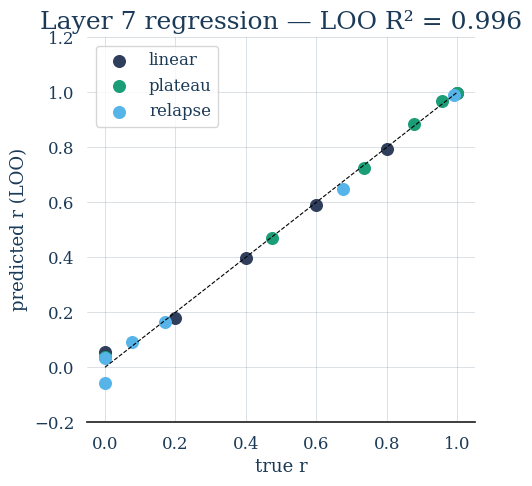

In [92]:
feature_cols = [c for c in df_session.columns
                if c not in ("trajectory", "session_idx", "r")]
X_feat = df_session[feature_cols].values
y_r    = df_session["r"].values

pipe_r = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])

y_pred_r = cross_val_predict(pipe_r, X_feat, y_r, cv=LeaveOneOut())
r2_loo   = r2_score(y_r, y_pred_r)
mse_loo  = mean_squared_error(y_r, y_pred_r)
print(f"Leave-one-session-out  R² = {r2_loo:.3f}   MSE = {mse_loo:.4f}")

pipe_r.fit(X_feat, y_r)
perm = permutation_importance(pipe_r, X_feat, y_r, n_repeats=20, random_state=0)
order = np.argsort(perm.importances_mean)[::-1]
print("\nPermutation importance (drop in R² when feature is shuffled):")
for i in order:
    print(f"  {feature_cols[i]:24s}  {perm.importances_mean[i]:+.3f} ± {perm.importances_std[i]:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
for shape in shapes:
    mask = df_session["trajectory"].values == shape
    ax.scatter(y_r[mask], y_pred_r[mask], label=shape, s=70)
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("true r"); ax.set_ylabel("predicted r (LOO)")
ax.set_title(f"Layer 7 regression — LOO R² = {r2_loo:.3f}")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.2, 1.2)
ax.legend(); ax.grid(alpha=0.3)
plt.show()

Silhouette (k=3, unsupervised): 0.514


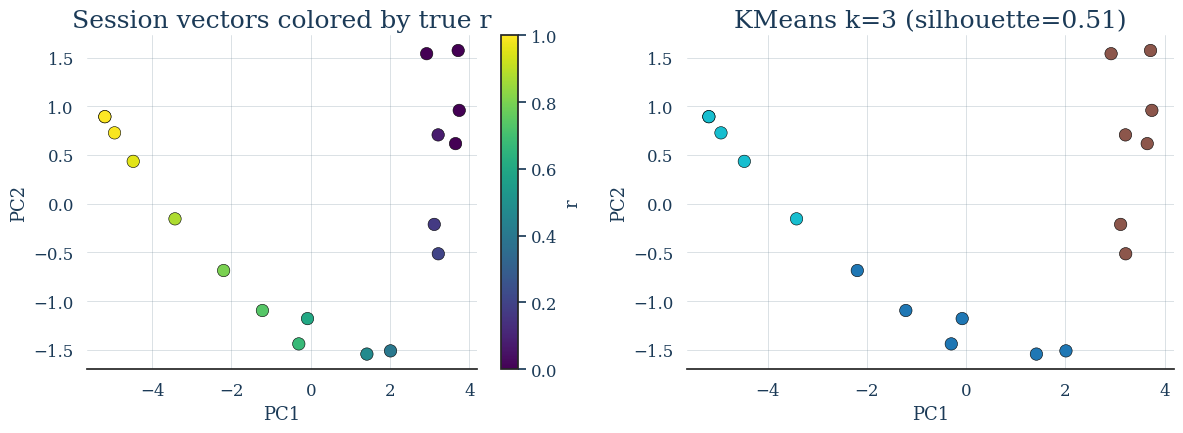


Cluster vs r-bin contingency:
  cluster 0: bin0=0, bin1=3, bin2=3
  cluster 1: bin0=7, bin1=0, bin2=0
  cluster 2: bin0=0, bin1=0, bin2=5


In [93]:
scaler_clu = StandardScaler().fit(X_feat)
X_std = scaler_clu.transform(X_feat)

km  = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_std)
sil = silhouette_score(X_std, km.labels_)
print(f"Silhouette (k=3, unsupervised): {sil:.3f}")

pca = PCA(n_components=2).fit(X_std)
pcs = pca.transform(X_std)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sc0 = ax[0].scatter(pcs[:, 0], pcs[:, 1], c=y_r, cmap="viridis",
                    s=80, edgecolor="k", linewidth=0.4)
ax[0].set_title("Session vectors colored by true r")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].grid(alpha=0.3)
plt.colorbar(sc0, ax=ax[0], label="r")
ax[1].scatter(pcs[:, 0], pcs[:, 1], c=km.labels_, cmap="tab10",
              s=80, edgecolor="k", linewidth=0.4)
ax[1].set_title(f"KMeans k=3 (silhouette={sil:.2f})")
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

r_bin = np.digitize(y_r, bins=[0.34, 0.67])
print("\nCluster vs r-bin contingency:")
for c in sorted(set(km.labels_)):
    mask = km.labels_ == c
    counts = Counter(r_bin[mask].tolist())
    print(f"  cluster {c}: " + ", ".join(f"bin{b}={counts.get(b,0)}" for b in (0,1,2)))

### Layer 7b — Parameter-Explicit & Cross-Prior Tests

Build a session panel where `(alpha, beta, gamma, delta_ms)` are sampled
independently (breaking the 1-D `r` manifold), then evaluate multi-output Ridge.
Cross-prior test: train on `prior_default`, evaluate on `prior_alt`.

In [94]:
n_param_sessions = 60
rng_panel  = np.random.default_rng(20240501)
degr_panel = DegradationModel(
    sfreq=sfreq, baseline_samples=BASELINE_SAMPLES,
    seed=int(rng_panel.integers(1 << 30)),
)

records_p = []
for s_idx in range(n_param_sessions):
    params = sample_params_uniform(rng_panel)
    X_deg  = degr_panel.degrade_session_params(x_eval, params, jitter=True)
    feats, _ = session_feature_vector(
        X_deg, y_eval, csp, ld, fe, baseline_cov=baseline_cov_eval,
    )
    feats.update({
        "alpha": params.alpha, "beta": params.beta,
        "gamma": params.gamma, "delta_ms": params.delta_ms,
        "session_idx": s_idx,
    })
    records_p.append(feats)

df_param = pd.DataFrame(records_p)
print("Multi-output panel:", df_param.shape)
for col in ("alpha", "beta", "gamma", "delta_ms"):
    print(f"  {col:9s}  [{df_param[col].min():.3f}, {df_param[col].max():.3f}]  "
          f"mean={df_param[col].mean():.3f}")

Multi-output panel: (60, 18)
  alpha      [0.400, 0.997]  mean=0.683
  beta       [0.005, 0.496]  mean=0.247
  gamma      [0.082, 2.426]  mean=1.324
  delta_ms   [0.070, 59.675]  mean=28.967


In [95]:
target_cols    = ["alpha", "beta", "gamma", "delta_ms"]
feature_cols_p = [c for c in df_param.columns
                  if c not in target_cols + ["session_idx"]]
X_p = df_param[feature_cols_p].values
Y_p = df_param[target_cols].values

pipe_multi = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
Y_pred_m   = cross_val_predict(pipe_multi, X_p, Y_p, cv=LeaveOneOut())

print("Per-axis Leave-one-session-out:")
print(f"  {'axis':10s}  {'R^2':>7s}   {'MSE':>8s}   {'MAE':>8s}")
for j, name in enumerate(target_cols):
    r2_j  = r2_score(Y_p[:, j], Y_pred_m[:, j])
    mse_j = mean_squared_error(Y_p[:, j], Y_pred_m[:, j])
    mae_j = float(np.mean(np.abs(Y_p[:, j] - Y_pred_m[:, j])))
    print(f"  {name:10s}  {r2_j:7.3f}   {mse_j:8.4f}   {mae_j:8.4f}")

pipe_multi.fit(X_p, Y_p)
print("\nPer-axis permutation importance (top-5 features):")
for j, name in enumerate(target_cols):
    pipe_axis = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))
    ]).fit(X_p, Y_p[:, j])
    perm_j = permutation_importance(pipe_axis, X_p, Y_p[:, j],
                                    n_repeats=15, random_state=0)
    order = np.argsort(perm_j.importances_mean)[::-1][:5]
    print(f"  [{name}]")
    for i in order:
        print(f"     {feature_cols_p[i]:24s}  "
              f"{perm_j.importances_mean[i]:+.3f} ± {perm_j.importances_std[i]:.3f}")

Per-axis Leave-one-session-out:
  axis            R^2        MSE        MAE
  alpha         0.997     0.0001     0.0067
  beta          0.443     0.0101     0.0801
  gamma         0.990     0.0052     0.0550
  delta_ms     -0.214   366.1178    15.9431

Per-axis permutation importance (top-5 features):
  [alpha]
     frob_dist_to_baseline     +0.142 ± 0.019
     mu_ratio_mean             +0.111 ± 0.017
     erd_mu_c4_mean            +0.084 ± 0.009
     erd_mu_c3_mean            +0.078 ± 0.009
     motor_relative_mean       +0.052 ± 0.006
  [beta]
     erd_lat_mu_abs_mean       +2.120 ± 0.299
     erd_lat_mu_mean           +1.206 ± 0.201
     frob_dist_to_baseline     +0.535 ± 0.107
     intertrial_cov_var        +0.140 ± 0.036
     mu_ratio_mean             +0.112 ± 0.033
  [gamma]
     lda_margin_std            +0.494 ± 0.046
     p2p_max_mean              +0.493 ± 0.072
     erd_lat_mu_abs_mean       +0.034 ± 0.004
     frob_dist_to_baseline     +0.024 ± 0.004
     mu_ratio_mean      

In [96]:
n_xprior_sessions = 30
r_grid_xp = np.linspace(0.0, 1.0, n_xprior_sessions)


def _build_panel(prior_fn, label, seed):
    degr_xp = DegradationModel(sfreq=sfreq, baseline_samples=BASELINE_SAMPLES, seed=seed)
    rows = []
    for k, r_val in enumerate(r_grid_xp):
        params = r_to_params(float(r_val), prior=prior_fn)
        X_deg  = degr_xp.degrade_session_params(x_eval, params, jitter=True)
        feats, _ = session_feature_vector(
            X_deg, y_eval, csp, ld, fe, baseline_cov=baseline_cov_eval,
        )
        feats.update({
            "r": float(r_val), "alpha": params.alpha, "beta": params.beta,
            "gamma": params.gamma, "delta_ms": params.delta_ms, "prior": label,
        })
        rows.append(feats)
    return pd.DataFrame(rows)


df_p1 = _build_panel(prior_default, "P1_default", seed=11)
df_p2 = _build_panel(prior_alt,     "P2_alt",     seed=22)

print("Prior comparison at r = 0.0, 0.5, 1.0 (alpha, beta, gamma, delta_ms):")
for r_v in (0.0, 0.5, 1.0):
    p1 = r_to_params(r_v, prior=prior_default)
    p2 = r_to_params(r_v, prior=prior_alt)
    print(f"  r={r_v:.1f}  P1={p1.alpha:.2f}/{p1.beta:.2f}/{p1.gamma:.2f}/{p1.delta_ms:5.1f}"
          f"   P2={p2.alpha:.2f}/{p2.beta:.2f}/{p2.gamma:.2f}/{p2.delta_ms:5.1f}")

target_meta = ("r", "alpha", "beta", "gamma", "delta_ms", "prior")
feat_xp = [c for c in df_p1.columns if c not in target_meta]

# Train on P1 (prior_default), test on P2 (prior_alt)
pipe_xp = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
pipe_xp.fit(df_p1[feat_xp].values, df_p1["r"].values)

r2_in = r2_score(df_p1["r"].values,
                 cross_val_predict(pipe_xp, df_p1[feat_xp].values,
                                   df_p1["r"].values, cv=LeaveOneOut()))
r2_xp = r2_score(df_p2["r"].values, pipe_xp.predict(df_p2[feat_xp].values))

print(f"\nIn-distribution R² (P1 LOO) : {r2_in:.3f}")
print(f"Cross-prior R²  (train P1, test P2): {r2_xp:.3f}")
print(f"Generalisation gap (R²_in - R²_xp) : {r2_in - r2_xp:.3f}")

Prior comparison at r = 0.0, 0.5, 1.0 (alpha, beta, gamma, delta_ms):
  r=0.0  P1=0.50/0.40/2.00/ 50.0   P2=0.40/0.50/2.00/ 80.0
  r=0.5  P1=0.75/0.20/1.00/ 25.0   P2=0.61/0.12/1.41/ 49.2
  r=1.0  P1=1.00/0.00/0.00/  0.0   P2=1.00/0.00/0.00/  0.0

In-distribution R² (P1 LOO) : 0.999
Cross-prior R²  (train P1, test P2): 0.601
Generalisation gap (R²_in - R²_xp) : 0.398


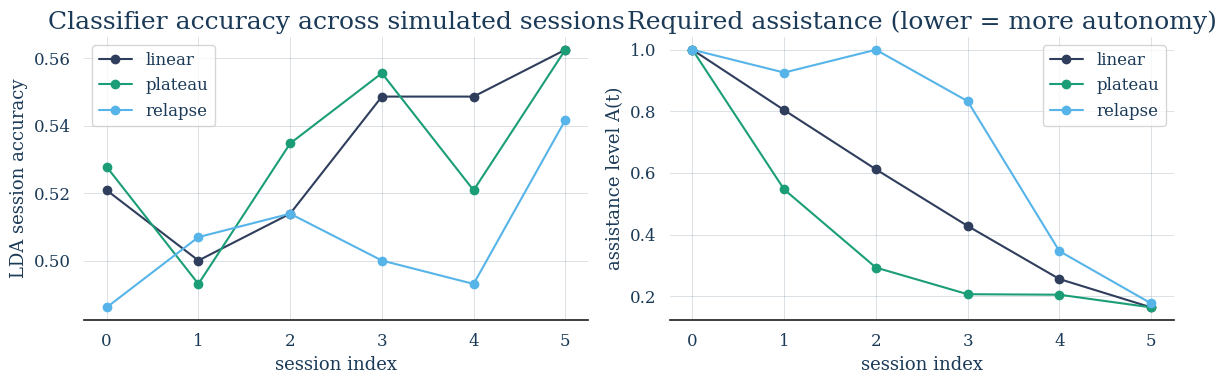

trajectory  session_idx     r  lda_session_acc  lda_conf_mean  assistance
    linear            0 0.000            0.521          0.983       1.000
    linear            1 0.200            0.500          0.980       0.804
    linear            2 0.400            0.514          0.970       0.612
    linear            3 0.600            0.549          0.953       0.428
    linear            4 0.800            0.549          0.930       0.256
    linear            5 1.000            0.562          0.836       0.164
   plateau            0 0.000            0.528          0.987       1.000
   plateau            1 0.475            0.493          0.955       0.547
   plateau            2 0.735            0.535          0.961       0.293
   plateau            3 0.878            0.556          0.903       0.207
   plateau            4 0.957            0.521          0.831       0.205
   plateau            5 1.000            0.562          0.836       0.164
   relapse            0 0.000         

In [97]:
# Assistance level: A(t) = 1 - confidence(t) * recovery_factor(t)
# High confidence + high r => low assistance (more autonomy for user).
df_session["assistance"] = 1.0 - df_session["lda_conf_mean"] * df_session["r"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for shape in shapes:
    sub = df_session[df_session["trajectory"] == shape].sort_values("session_idx")
    ax[0].plot(sub["session_idx"], sub["lda_session_acc"], marker="o", label=shape)
    ax[1].plot(sub["session_idx"], sub["assistance"],      marker="o", label=shape)

ax[0].set(xlabel="session index", ylabel="LDA session accuracy",
          title="Classifier accuracy across simulated sessions")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set(xlabel="session index", ylabel="assistance level A(t)",
          title="Required assistance (lower = more autonomy)")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(df_session[[
    "trajectory", "session_idx", "r",
    "lda_session_acc", "lda_conf_mean", "assistance",
]].round(3).to_string(index=False))

### Calibration Sufficiency — Rule-Based Stopping Controller

Decides when a subject has provided enough trials to reliably fit CSP + LDA.
Evaluates five criteria every `chunk_size` new accepted trials:

| Criterion | Signal | Threshold |
|---|---|---|
| Accuracy | 3-fold CV on calibration pool | ≥ 0.72 |
| Confidence mean | mean LDA `P(correct class)` | ≥ 0.62 |
| Confidence stability | std of LDA confidence | ≤ 0.14 |
| Rejection rate | fraction flagged by global acceptance model | ≤ 0.35 |
| Feature drift | Frobenius drift vs previous chunk | ≤ 0.80 (relative) |

Stops when all five hold for `patience=2` consecutive checks.
The rejection rate criterion uses the **frozen global acceptance model** (`rqe` + `accept_model`).

### Healthy vs Patient Domain Profiling

At the end of calibration, the session-level feature vector (13-d) is used to
characterize where a new subject sits relative to a healthy reference distribution.

**Design rules (zero-shot generalisation):**
- Scaler and PCA fitted on healthy reference sessions only, then frozen.
- Clustering is unsupervised — no group labels used during fitting.
- Labels used only post-hoc to evaluate cluster composition.

Healthy proxy: high `r` sessions (0.85–1.00). Patient proxy: low `r` (0.00–0.25).

In [98]:
healthy_r_values = [0.85, 0.90, 0.95, 1.00]
patient_r_values = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]

degr_hp = DegradationModel(sfreq=sfreq, baseline_samples=BASELINE_SAMPLES, seed=77)
baseline_cov_hp = np.mean(
    np.stack([np.cov(ep[..., BASELINE_SAMPLES:]) for ep in x_eval]), axis=0,
)

healthy_records, patient_records = [], []
for r_val in healthy_r_values:
    X_deg = degr_hp.degrade_session(x_eval, r_val, jitter=True)
    feats, _ = session_feature_vector(X_deg, y_eval, csp, ld, fe,
                                      baseline_cov=baseline_cov_hp)
    feats.update({"group": "healthy", "r_true": float(r_val)})
    healthy_records.append(feats)

for r_val in patient_r_values:
    X_deg = degr_hp.degrade_session(x_eval, r_val, jitter=True)
    feats, _ = session_feature_vector(X_deg, y_eval, csp, ld, fe,
                                      baseline_cov=baseline_cov_hp)
    feats.update({"group": "patient", "r_true": float(r_val)})
    patient_records.append(feats)

df_hp = pd.DataFrame(healthy_records + patient_records).reset_index(drop=True)
hp_feature_cols = [c for c in df_hp.columns if c not in ("group", "r_true")]
print(df_hp[["group", "r_true"] + hp_feature_cols[:4]].to_string(index=False))

  group  r_true  erd_mu_c3_mean  erd_mu_c4_mean  erd_lat_mu_mean  erd_lat_mu_abs_mean
healthy    0.85       -0.216488       -0.295788         0.079300             0.293210
healthy    0.90       -0.273330       -0.374900         0.101570             0.311445
healthy    0.95       -0.342038       -0.459658         0.117620             0.332706
healthy    1.00       -0.412690       -0.546073         0.133383             0.355319
patient    0.00        0.401641        0.460881        -0.059240             0.227042
patient    0.05        0.334410        0.424362        -0.089951             0.286287
patient    0.10        0.369257        0.393130        -0.023873             0.254485
patient    0.15        0.351407        0.381593        -0.030186             0.237559
patient    0.20        0.316393        0.352746        -0.036353             0.257464
patient    0.25        0.292556        0.321217        -0.028661             0.217306


KMeans (k=2) silhouette: 0.821

Cluster composition (post-hoc):
  cluster 0: {'patient': 6}  (n=6)
  cluster 1: {'healthy': 4}  (n=4)


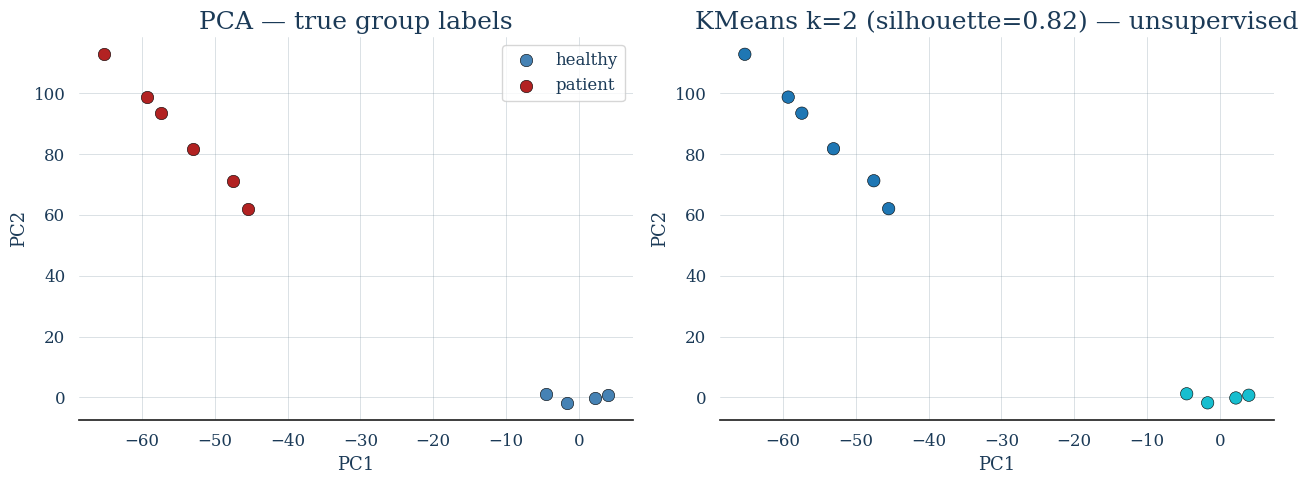

In [99]:
X_feat_hp  = df_hp[hp_feature_cols].values
groups     = df_hp["group"].values
r_true_hp  = df_hp["r_true"].values

healthy_mask = groups == "healthy"
patient_mask = groups == "patient"

scaler_hp = StandardScaler().fit(X_feat_hp[healthy_mask])
X_std_hp  = scaler_hp.transform(X_feat_hp)

pca_hp = PCA(n_components=2).fit(X_std_hp[healthy_mask])
pcs_hp = pca_hp.transform(X_std_hp)

km_hp  = KMeans(n_clusters=2, n_init=20, random_state=0).fit(X_std_hp)
sil_hp = silhouette_score(X_std_hp, km_hp.labels_)
print(f"KMeans (k=2) silhouette: {sil_hp:.3f}")

print("\nCluster composition (post-hoc):")
for c in sorted(set(km_hp.labels_)):
    mask = km_hp.labels_ == c
    comp = Counter(groups[mask])
    print(f"  cluster {c}: {dict(comp)}  (n={mask.sum()})")

group_colors = {"healthy": "steelblue", "patient": "firebrick"}
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for g, col in group_colors.items():
    m = groups == g
    axs[0].scatter(pcs_hp[m, 0], pcs_hp[m, 1], c=col, label=g, s=80,
                   edgecolor="k", linewidth=0.4)
axs[0].set_title("PCA — true group labels")
axs[0].set_xlabel("PC1"); axs[0].set_ylabel("PC2")
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].scatter(pcs_hp[:, 0], pcs_hp[:, 1], c=km_hp.labels_, cmap="tab10",
               s=80, edgecolor="k", linewidth=0.4)
axs[1].set_title(f"KMeans k=2 (silhouette={sil_hp:.2f}) — unsupervised")
axs[1].set_xlabel("PC1"); axs[1].set_ylabel("PC2"); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [100]:
# Feature discriminability: Cohen's d per feature, Mann-Whitney U test,
# and LR permutation importance.

def cohens_d(a, b):
    pooled_std = np.sqrt((np.std(a, ddof=1) ** 2 + np.std(b, ddof=1) ** 2) / 2)
    return (np.mean(a) - np.mean(b)) / (pooled_std + 1e-12)


H = X_std_hp[healthy_mask]
P = X_std_hp[patient_mask]

effect_sizes, pvals = {}, {}
for j, name in enumerate(hp_feature_cols):
    d        = cohens_d(H[:, j], P[:, j])
    _, p     = sp_stats.mannwhitneyu(H[:, j], P[:, j], alternative="two-sided")
    effect_sizes[name] = d
    pvals[name]        = p

sorted_feats = sorted(effect_sizes, key=lambda k: abs(effect_sizes[k]), reverse=True)
print("Feature discriminability (healthy vs patient):")
print(f"  {'feature':28s}  {'Cohen d':>8s}  {'MWU p':>9s}  sig")
for name in sorted_feats:
    sig = "*" if pvals[name] < 0.05 else ""
    print(f"  {name:28s}  {effect_sizes[name]:+8.3f}  {pvals[name]:9.4f}  {sig}")

y_hp_bin = (groups == "patient").astype(int)
lr_hp = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000)
lr_hp.fit(X_std_hp, y_hp_bin)
perm_hp = permutation_importance(lr_hp, X_std_hp, y_hp_bin,
                                  n_repeats=20, random_state=0)
perm_order = np.argsort(perm_hp.importances_mean)[::-1]
print("\nPermutation importance (LR, healthy vs patient):")
for i in perm_order:
    print(f"  {hp_feature_cols[i]:28s}  {perm_hp.importances_mean[i]:+.3f} "
          f"± {perm_hp.importances_std[i]:.3f}")

Feature discriminability (healthy vs patient):
  feature                        Cohen d      MWU p  sig
  motor_relative_mean            +10.911     0.0095  *
  frob_dist_to_baseline           -9.953     0.0095  *
  erd_mu_c3_mean                  -9.925     0.0095  *
  erd_mu_c4_mean                  -9.617     0.0095  *
  lda_margin_mean                 -9.511     0.0095  *
  intertrial_cov_var              +8.015     0.0095  *
  mu_ratio_mean                   +7.543     0.0095  *
  p2p_max_mean                    -6.598     0.0095  *
  erd_lat_mu_mean                 +6.286     0.0095  *
  lda_margin_std                  -5.888     0.0095  *
  lda_conf_mean                   -3.283     0.0095  *
  erd_lat_mu_abs_mean             +2.960     0.0095  *
  lda_session_acc                 +1.011     0.2381  

Permutation importance (LR, healthy vs patient):
  p2p_max_mean                  +0.470 ± 0.171
  lda_session_acc               +0.000 ± 0.000
  intertrial_cov_var            +0.000